In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.metrics import r2_score,roc_curve,roc_auc_score,accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression

In [73]:

df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [74]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [75]:
df.shape

(920, 16)

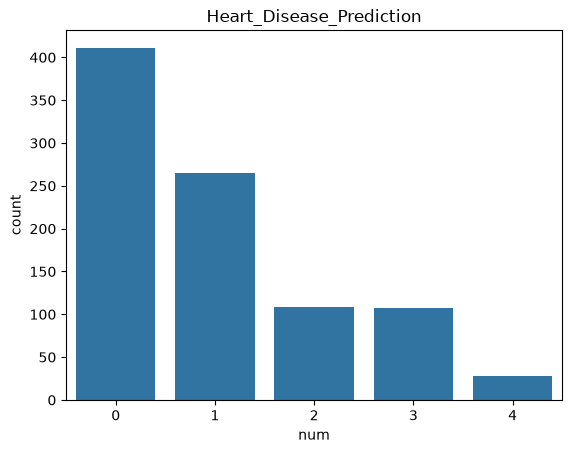

In [76]:
sns.countplot(x='num',data=df)
plt.title("Heart_Disease_Prediction")
plt.show()

In [77]:
df['target']=(df['num']>0).astype(int)
df[['num','target']].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


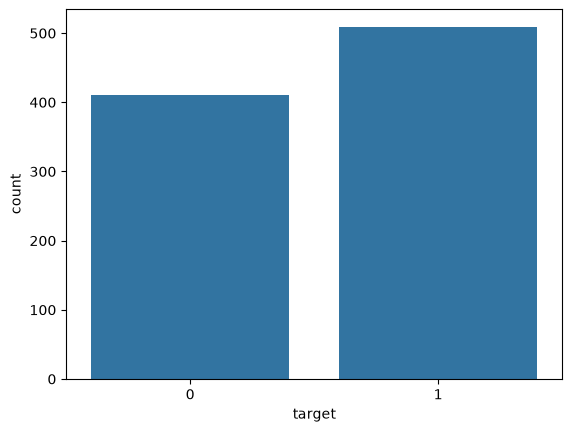

In [78]:
sns.countplot(x='target',data=df)
plt.show()

In [79]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [80]:
x=df.drop(['id','target','num'],axis=1)
y=df['target']

In [81]:
x.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

In [82]:
for col in df.columns:
    print(col, df[col].dtype, df[col].dtype.name)

id int64 int64
age int64 int64
sex str str
dataset str str
cp str str
trestbps float64 float64
chol float64 float64
fbs object object
restecg str str
thalch float64 float64
exang object object
oldpeak float64 float64
slope str str
ca float64 float64
thal str str
num int64 int64
target int64 int64


In [83]:
for col in x.columns:
    if x[col].dtype.name in ['object','str','string']:
       x[col]=x[col].fillna(x[col].mode()[0])

    else:
        x[col]=x[col].fillna(x[col].median())

In [84]:
x.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [85]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in x.select_dtypes(include='object').columns:
    x[col]=le.fit_transform(x[col])

C:\Users\AL HAMD TRADERS\AppData\Local\Temp\ipykernel_3388\2510283620.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in x.select_dtypes(include='object').columns:


In [86]:
x.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1


In [87]:
x_trian,x_test,y_trian,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [88]:
lo=LogisticRegression(max_iter=1000)
lo.fit(x_trian,y_trian)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [91]:
y_pred=lo.predict(x_test)
print(y_pred)

[0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0
 0 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0
 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0
 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1 0 1]


In [92]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy Score",accuracy)

Accuracy Score 0.7989130434782609


In [93]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[63 12]
 [25 84]]


In [94]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        75
           1       0.88      0.77      0.82       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184



Conclusion:
A Logistic Regression model was trained on the preprocessed data and achieved an accuracy of 79%, with an AUC score indicating strong discriminative ability between diseased and healthy patients. The classification report showed that the model performed well in identifying positive cases, though recall for the diseased class can be further improved to minimize missed diagnoses.